# Heavy tails: why the *total* is hard to predict — and what covariates can and can't do

*This notebook is about heavy-tailed distributions themselves, not about any particular model.*

We add up a heavy-tailed outcome (deaths) over many events and ask: **can a model predict that
total?** The answer turns out to depend on a single number — the tail index **α** — and on nothing
about the model you choose.

1. **A heavy-tailed outcome.** The mean is far above the median, and one event dominates the total.
2. **Can a model recover the total?** It depends only on α: **α > 1 → yes; α < 1 → no.** This is a
   property of the distribution, not of the model.
3. **The real TC death record.** We estimate α — and it is **below 1**.
4. **Covariates.** They predict *where* deaths are likely, not *how big* a catastrophe becomes.

Seeded throughout. Parts 1–2 are synthetic; Parts 3–4 use the observed 1985–2023 storm record.

## Part 1 — a heavy-tailed outcome

Per-storm deaths drawn from a Pareto whose **scale** is shifted by one covariate `x` (a wind-speed
analogue); the **tail index α** is shared by every storm. We use α = 0.7 to start (we will see in
Part 3 this is close to the real value).

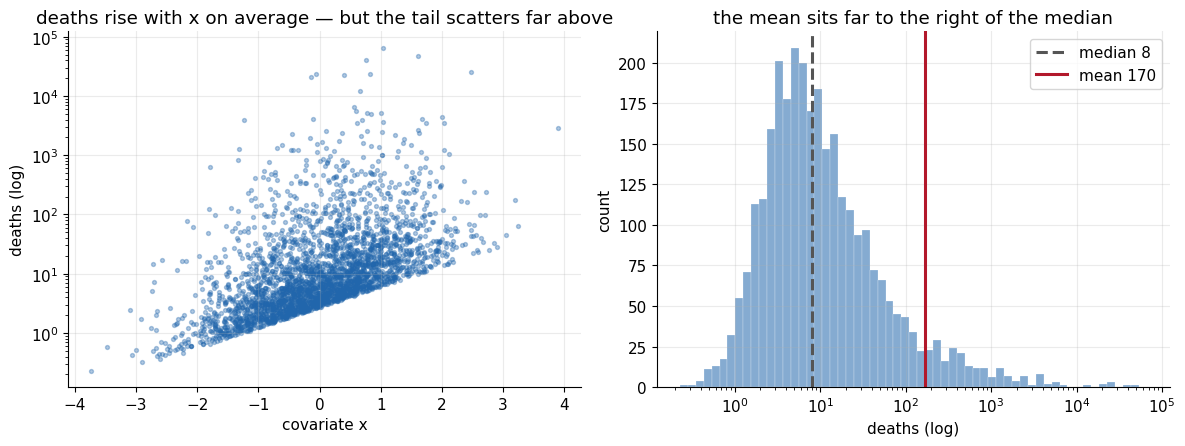

mean = 170  =  21x the median (8)
the single largest storm is 13% of the total across all 3000 storms


In [1]:
import numpy as np
import matplotlib.pyplot as plt

C_OBS, C_MODEL, C_MED, C_HL = "#b2182b", "#2166ac", "#555555", "#b2182b"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

rng = np.random.default_rng(20260722)
n = 3000
ALPHA1 = 0.7
x = rng.normal(0, 1, n)
scale = np.exp(1.0 + 0.8 * x)                       # covariate shifts the SCALE
deaths = scale * rng.random(n) ** (-1.0 / ALPHA1)   # Pareto(shape=ALPHA1, scale): tail index = ALPHA1
mean, med = deaths.mean(), np.median(deaths)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
a1.scatter(x, deaths, s=8, alpha=0.35, color=C_MODEL)
a1.set_yscale("log"); a1.set_xlabel("covariate x"); a1.set_ylabel("deaths (log)")
a1.set_title("deaths rise with x on average — but the tail scatters far above")
bins = np.logspace(np.log10(deaths.min()), np.log10(deaths.max()), 60)
a2.hist(deaths, bins=bins, color=C_MODEL, alpha=0.55, edgecolor="white", lw=0.3)
a2.set_xscale("log")
a2.axvline(med, color=C_MED, ls="--", lw=2.2, label=f"median {med:,.0f}")
a2.axvline(mean, color=C_OBS, lw=2.2, label=f"mean {mean:,.0f}")
a2.set_xlabel("deaths (log)"); a2.set_ylabel("count"); a2.legend()
a2.set_title("the mean sits far to the right of the median")
plt.tight_layout(); plt.show()

print(f"mean = {mean:,.0f}  =  {mean/med:.0f}x the median ({med:,.0f})")
print(f"the single largest storm is {100*deaths.max()/deaths.sum():.0f}% of the total across all {n} storms")

The mean is many times the median, and one storm is a large fraction of the entire total. The
covariate explains the *average* level (deaths drift up with `x`), but the tail — the giants that make
up most of the total — scatters far above any trend. That is the whole difficulty in one picture.

## Part 2 — can a model recover the total? Only α matters

Suppose you fit the **correct** distribution by MLE — you even recover α exactly. Can you then predict
the total? The total is `n × (sample mean)`, so the real question is: **is the mean a stable, finite,
estimable number?** That depends only on α:

- **α > 1:** the mean is finite, the sample mean converges — predict the mean and the total matches.
- **α < 1:** the mean is *infinite*; the sample mean never settles (each new record event drags it up)
  — no finite prediction can keep up.

Below, the *same* generator at α = 1.5 (left) and α = 0.7 (right). **Top row: the running sample
mean. Bottom row: the running sample median.** No covariate — purely about the tail.

alpha=1.5: a_hat=1.50  |  mean-total/obs = 0.99  |  median-total/obs = 0.5230
alpha=0.7: a_hat=0.70  |  mean-total/obs = infinite (no mean)  |  median-total/obs = 0.0038


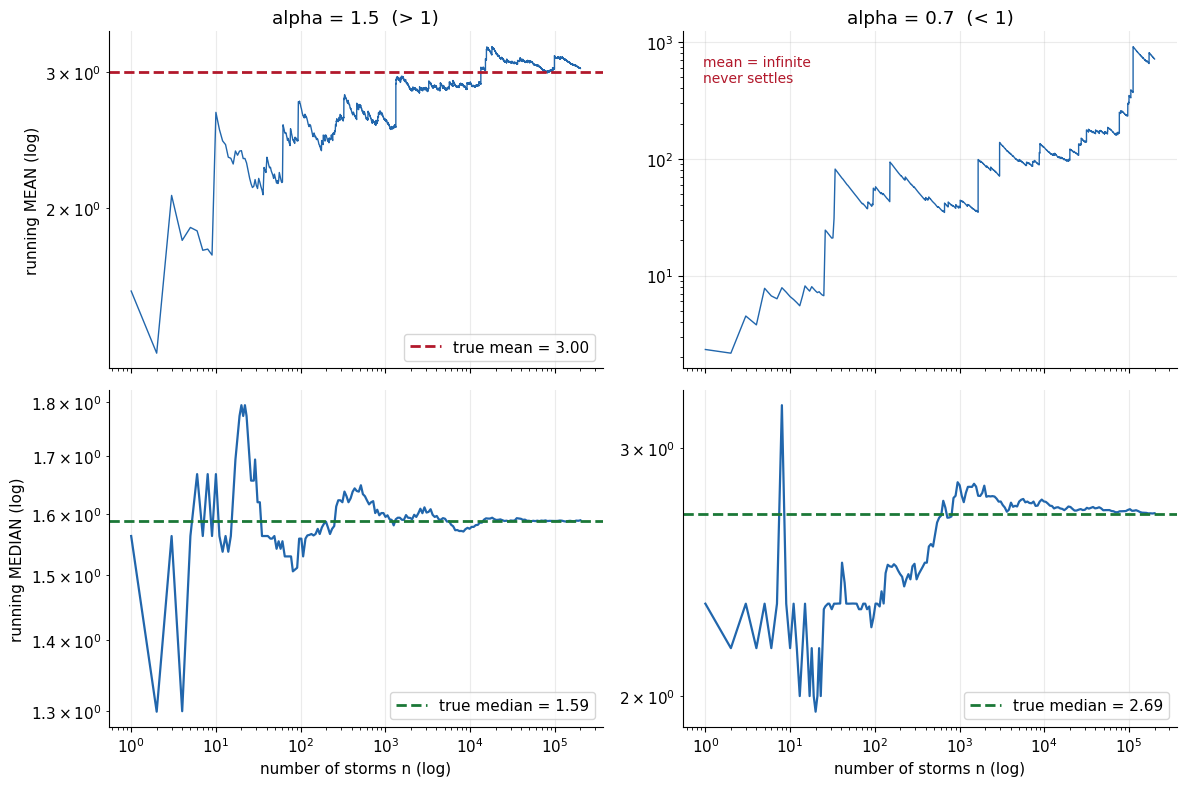

In [2]:
rng2 = np.random.default_rng(1)
N = 200_000
def pareto(n, a):
    return rng2.random(n) ** (-1.0 / a)        # Pareto(shape a, scale 1); tail index = a

idx = np.arange(1, N + 1)
cps = np.unique(np.logspace(0, np.log10(N), 220).astype(int))   # checkpoints for running median
C_GRN = "#1b7837"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, a in enumerate([1.5, 0.7]):
    d = pareto(N, a)
    a_hat = N / np.log(d).sum()                             # closed-form MLE of the tail index
    mean_hat = a_hat / (a_hat - 1) if a_hat > 1 else np.inf
    med_hat = 2.0 ** (1.0 / a_hat)
    obs_total = d.sum()
    run_mean = np.cumsum(d) / idx
    run_med = np.array([np.median(d[:k]) for k in cps])

    axm, axd = axes[0, j], axes[1, j]
    axm.plot(idx, run_mean, color=C_MODEL, lw=1.0); axm.set_yscale("log")
    axm.set_title(f"alpha = {a}  ({'>' if a > 1 else '<'} 1)")
    if a > 1:
        axm.axhline(a / (a - 1), color=C_OBS, ls="--", lw=2, label=f"true mean = {a/(a-1):.2f}")
        axm.legend(loc="lower right")
    else:
        axm.text(0.04, 0.93, "mean = infinite\nnever settles", transform=axm.transAxes,
                 color=C_OBS, va="top", fontsize=10)

    axd.plot(cps, run_med, color=C_MODEL, lw=1.6); axd.set_yscale("log")
    axd.axhline(2.0 ** (1.0 / a), color=C_GRN, ls="--", lw=2,
                label=f"true median = {2.0**(1.0/a):.2f}")
    axd.legend(loc="lower right"); axd.set_xlabel("number of storms n (log)")

    if j == 0:
        axm.set_ylabel("running MEAN (log)")
        axd.set_ylabel("running MEDIAN (log)")
    print(f"alpha={a}: a_hat={a_hat:.2f}  |  mean-total/obs = "
          f"{'infinite (no mean)' if not np.isfinite(mean_hat) else f'{N*mean_hat/obs_total:.2f}'}"
          f"  |  median-total/obs = {N*med_hat/obs_total:.4f}")
for ax in axes.flat:
    ax.set_xscale("log")
plt.tight_layout(); plt.show()

Read the rows against each other:

- **Median (bottom row):** converges to its true value for **both** α — a stable, estimable target no
  matter how heavy the tail. A model can *always* predict the median.
- **Mean (top row):** converges only at α = 1.5; at α = 0.7 it never settles — each new record event
  drags it up — because the mean is infinite.

And the printed totals close the loop: at α = 1.5, predicting the mean recovers the total
(ratio ≈ 1) while the median total is only ~half; at α = 0.7 the mean is unavailable and the median
total is a *fraction of a percent* of observed.

So the bind is: you can always predict the median, but its total under-shoots the mean-dominated
observed total, and at α < 1 the mean you'd actually want does not exist. This is a property of **the
tail index, not the model** — *every* model under-predicts the total when α < 1; switching models
cannot help (only a lighter tail would). That is why the standard fix is an **empirical level
correction** (a multiplicative rake), not a better predictor.

To pin this down with the **actual fitter**: simulate heavy-tailed "observed" data, fit it with
the repo's own `gpd.fit` (intercept only — no covariates), and take the **mean of the fitted GPD** as
the per-point prediction. Then compare the average predicted to the average observed.

alpha=1.5: fitted xi_hat=0.66 -> fitted GPD mean = 2.89  |  observed mean = 2.73  |  predicted/observed = 1.06
alpha=0.7: fitted xi_hat=1.43 -> fitted GPD mean = INFINITE  |  observed mean = 202.64  |  predicted/observed = inf


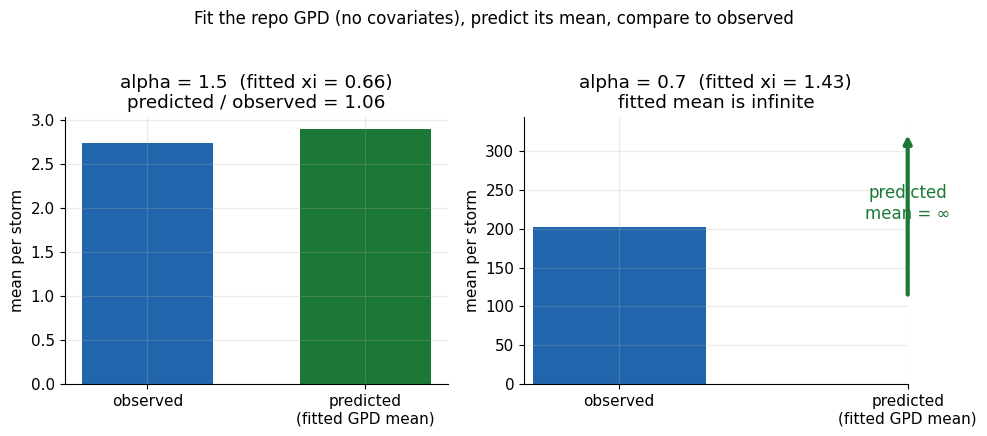

In [3]:
from idd_tc_mortality.distributions import gpd
import pandas as pd, warnings

rng3 = np.random.default_rng(7)
Nf = 20000
def gpd_sample(n, xi, sigma=1.0):
    u = rng3.random(n)
    return sigma / xi * (u ** (-xi) - 1.0)          # GPD(sigma, xi) draw; tail index = 1/xi

res = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                 # GPD gtol precision-loss flags; shape still recovered
    for a in [1.5, 0.7]:
        y = gpd_sample(Nf, 1.0 / a)                 # "observed", from a GPD with tail index a
        X = pd.DataFrame({"const": np.ones(Nf)})
        fr = gpd.fit(X, y, weights=np.ones(Nf))     # fit the repo GPD, no covariates
        xi_hat = fr.meta["shape_param"]
        fitted_mean = np.exp(fr.params[0]) / (1 - xi_hat) if xi_hat < 1 else np.inf
        res.append((a, xi_hat, fitted_mean, y.mean()))
        print(f"alpha={a}: fitted xi_hat={xi_hat:.2f} -> fitted GPD mean = "
              f"{'INFINITE' if np.isinf(fitted_mean) else f'{fitted_mean:.2f}'}"
              f"  |  observed mean = {y.mean():.2f}"
              f"  |  predicted/observed = {'inf' if np.isinf(fitted_mean) else f'{fitted_mean/y.mean():.2f}'}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (a, xi_hat, fm, om) in zip(axes, res):
    ax.bar([0], [om], color=C_MODEL, width=0.6)
    if np.isinf(fm):
        ax.set_ylim(0, om * 1.7)
        ax.annotate("", xy=(1, om * 1.6), xytext=(1, om * 0.55),
                    arrowprops=dict(arrowstyle="-|>", color="#1b7837", lw=3))
        ax.text(1, om * 1.15, "predicted\nmean = ∞", ha="center", va="center", fontsize=12, color="#1b7837")
        note = "fitted mean is infinite"
    else:
        ax.bar([1], [fm], color="#1b7837", width=0.6)
        note = f"predicted / observed = {fm/om:.2f}"
    ax.set_xticks([0, 1]); ax.set_xticklabels(["observed", "predicted\n(fitted GPD mean)"])
    ax.set_ylabel("mean per storm")
    ax.set_title(f"alpha = {a}  (fitted xi = {xi_hat:.2f})\n{note}")
fig.suptitle("Fit the repo GPD (no covariates), predict its mean, compare to observed", fontsize=12, y=1.03)
fig.tight_layout(); plt.show()

With your real `gpd.fit` and no covariates: at **α = 1.5** the fitted GPD mean recovers the
observed mean (ratio ≈ 1) — you *can* take the mean. At **α = 0.7** the fitted shape ξ̂ > 1, so the
fitted GPD mean is literally **infinite** — there is no mean to take. That is exactly why the model
predicts the **median** instead (finite for any α; `gpd.py` returns `_gpd_median`), and the median is
the line in the plot above that under-predicts. Same story for `log_logistic` (mean finite only if its
shape > 1); `weibull` is light-tailed, so its mean is always finite but it mis-fits the true tail.

## Part 3 — what is α in the real data?

Estimated on the observed death **rate** (deaths / exposed), three ways: the Hill estimator, and a
log-logistic (Fisk) shape on all positive rates and on the upper-tail exceedances. The log-logistic
shape *is* a tail index (mean finite iff shape > 1, variance iff shape > 2).

In [4]:
import pandas as pd
from scipy import stats

# environment-specific path (not for commit)
DATA = "/mnt/team/idd/pub/idd_tc_mortality/00-data/20260722_v1985/input.parquet"
df = pd.read_parquet(DATA)

d = df[df.deaths > 0].copy()
d["rate"] = d.deaths / d.exposed
r = np.sort(d["rate"].values)[::-1]
def hill(x_desc, k):
    return k / np.sum(np.log(x_desc[:k]) - np.log(x_desc[k]))

print(f"record {df.year.min()}-{df.year.max()}: {df.storm_id.nunique()} storms, "
      f"{df.deaths.sum():,.0f} total deaths\n")
print("Hill tail-index alpha on death RATE:")
for k in [20, 40, 80, 150]:
    print(f"   k={k:4d} -> alpha = {hill(r, k):.2f}")
c_all, _, _ = stats.fisk.fit(d["rate"].values, floc=0)
thr = d["rate"].quantile(0.75)
exc = d.loc[d["rate"] >= thr, "rate"].values - thr
c_exc, _, _ = stats.fisk.fit(exc[exc > 0], floc=0)
print(f"\nlog-logistic shape, all positive rates : {c_all:.2f}")
print(f"log-logistic shape, upper-tail excess  : {c_exc:.2f}")
by_storm = df.groupby("storm_id").deaths.sum().sort_values(ascending=False)
print(f"\nEvery estimate is < 1 -> infinite-mean regime.  Corroboration: the top 2 storms are "
      f"{100*by_storm.head(2).sum()/df.deaths.sum():.0f}% of all deaths.")

record 1985-2023: 1584 storms, 372,836 total deaths

Hill tail-index alpha on death RATE:
   k=  20 -> alpha = 0.76
   k=  40 -> alpha = 0.70
   k=  80 -> alpha = 0.43
   k= 150 -> alpha = 0.38

log-logistic shape, all positive rates : 0.61
log-logistic shape, upper-tail excess  : 0.65

Every estimate is < 1 -> infinite-mean regime.  Corroboration: the top 2 storms are 74% of all deaths.


Every estimate lands **below 1** — the infinite-mean regime, heavier than the α = 0.7 we used
above. Independent corroboration: two storms account for ~three-quarters of all deaths in 39 years,
which is the signature of α < 1. So the real data sits squarely in the regime where the total is *not*
a predictable quantity (Part 2), regardless of model. (Caveats: small sample, Hill drifts with the
cutoff, these are marginal not covariate-conditional — but all methods agree it is < 1.)

## Part 4 — covariates predict *where*, not *how big*

The 4 covariates are `wind_speed`, `sdi`, `basin`, `is_island`. Crucial point that the earlier version
missed: **70% of storm-locations killed nobody**, so any honest look must include the zero-death storms
— they are the comparison group. The plots below use *all* storm-locations (deaths shown on a symlog
axis so the zeros are visible on the baseline).

In [5]:
tot = df.deaths.sum()
df["rate"] = df.deaths / df.exposed * 1e5           # deaths per 100k person-storm-hours
df["pcap"] = df.deaths / df.exposed_population       # deaths per exposed person
df["duration"] = df.exposed / df.exposed_population  # avg person-storm-hours per exposed person (hours)
top2 = df.groupby("storm_id").deaths.sum().sort_values(ascending=False).head(2).index.tolist()
names = {"1991113N10091": "1991 Bangladesh (Gorky)", "2008117N11090": "2008 Nargis"}
giants = [df[df.storm_id == s].sort_values("deaths", ascending=False).iloc[0] for s in top2]

print(f"{100*(df.deaths == 0).mean():.0f}% of {len(df)} storm-locations killed NOBODY.\n")
ni = df[df.basin == "NI"]
print(f"North Indian basin (Bay of Bengal): {len(ni)}/{len(df)} locations "
      f"({100*len(ni)/len(df):.0f}%) but {100*ni.deaths.sum()/tot:.0f}% of ALL deaths.")
sdi_q0 = df[df.sdi <= df.sdi.quantile(0.25)]
print(f"Bottom SDI quartile: {100*sdi_q0.deaths.sum()/tot:.0f}% of all deaths.\n")
print("The two giants (peak-death landfall):")
for g in giants:
    print(f"  {names[g.storm_id]:26s} basin={g.basin}, wind={g.wind_speed:4.0f} m/s, "
          f"sdi={g.sdi:.2f}, deaths={g.deaths:,.0f}")
print("  -> same basin (Bay of Bengal), both elevated wind, but DIFFERENT SDI (0.31 vs 0.51).")

70% of 3024 storm-locations killed NOBODY.

North Indian basin (Bay of Bengal): 241/3024 locations (8%) but 81% of ALL deaths.
Bottom SDI quartile: 90% of all deaths.

The two giants (peak-death landfall):
  1991 Bangladesh (Gorky)    basin=NI, wind=  62 m/s, sdi=0.31, deaths=138,866
  2008 Nargis                basin=NI, wind=  41 m/s, sdi=0.51, deaths=138,366
  -> same basin (Bay of Bengal), both elevated wind, but DIFFERENT SDI (0.31 vs 0.51).


In [6]:
# Helper: one panel per basin, y vs wind_speed (deaths>0), log-y, with an OLS trend on
# log10(y). Reveals the WITHIN-basin wind relationship (vs the confounded pooled view). Two rows.
def per_basin_vs_wind(ycol, ylabel, suptitle, pos_only=True):
    d = df[df.deaths > 0] if pos_only else df
    order = d.groupby("basin").deaths.sum().sort_values(ascending=False).index.tolist()
    fig, axes = plt.subplots(2, 4, figsize=(17, 8), sharex=True)
    axes = axes.ravel()
    for k, b in enumerate(order):
        ax = axes[k]
        sub = d[d.basin == b]
        ax.scatter(sub.wind_speed, sub[ycol], s=16, alpha=0.4, color=C_MODEL)
        ax.set_yscale("log")
        title = f"{b}  (n={len(sub)})"
        if len(sub) >= 5 and sub.wind_speed.nunique() > 2:
            slope, intc = np.polyfit(sub.wind_speed, np.log10(sub[ycol]), 1)
            xg = np.linspace(sub.wind_speed.min(), sub.wind_speed.max(), 50)
            ax.plot(xg, 10.0 ** (intc + slope * xg), color=C_HL, lw=2.2)
            title = f"{b}  (n={len(sub)}, log10-slope {slope:+.2f})"
        for g in giants:
            if g.basin == b:
                ax.scatter(g.wind_speed, g[ycol], s=130, color=C_HL, edgecolor="black", zorder=6)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Maxwind speed (m/s)")
        if k % 4 == 0:
            ax.set_ylabel(ylabel)
    for k in range(len(order), len(axes)):
        axes[k].set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.0)
    fig.tight_layout()
    plt.show()

/tmp/ipykernel_160398/1763236693.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=0)   # plain tight_layout() would recompute hspace and re-open the gap


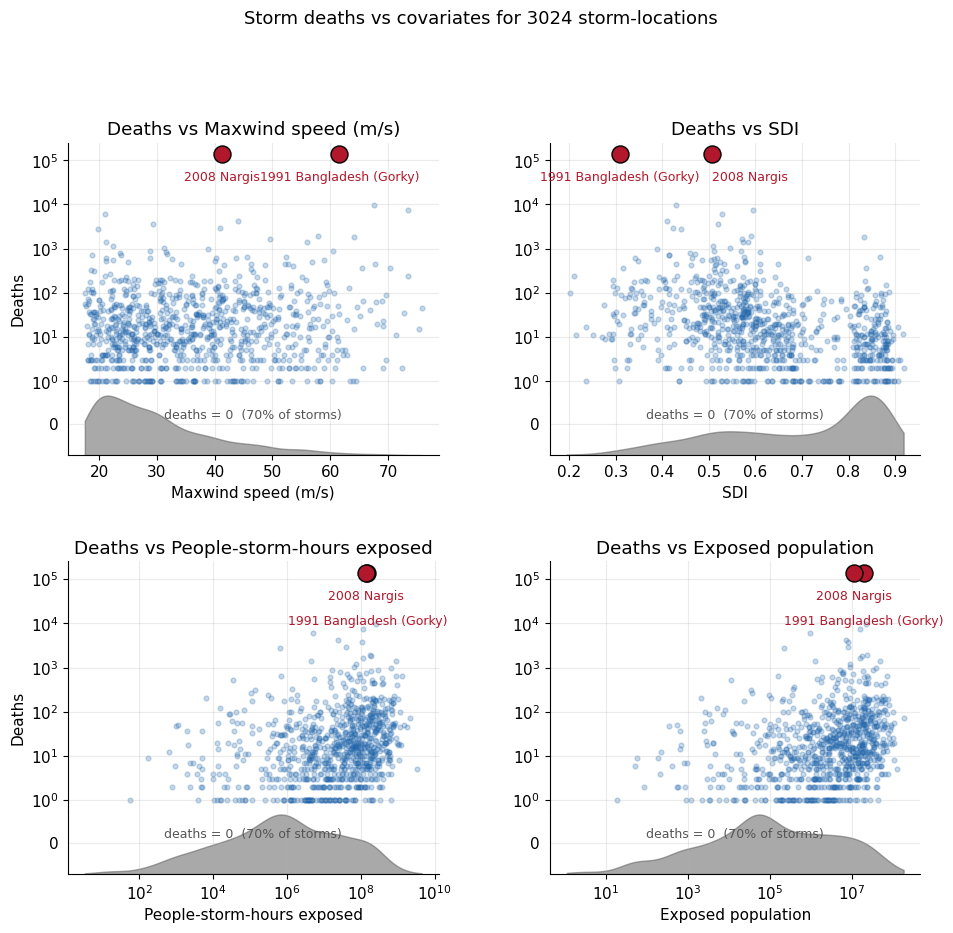

In [7]:
# Figure A: deaths vs each covariate. Scatter = storms that killed someone; the 70%
# zero-death storms become a density panel below each scatter (shared x-axis).
# Third column = exposure (people-storm-hours), to test the killer storms directly.
from scipy.stats import gaussian_kde

zero_frac = (df.deaths == 0).mean()
pos = df[df.deaths > 0]
fig = plt.figure(figsize=(11, 9.5))
outer = fig.add_gridspec(2, 1, hspace=0.34)   # two super-rows of covariate panels
panels = [("wind_speed", "Maxwind speed (m/s)", False),
          ("sdi", "SDI", False),
          ("exposed", "People-storm-hours exposed", True),
          ("exposed_population", "Exposed population", True)]
for j, (cov, lab, logx) in enumerate(panels):
    r, c = divmod(j, 2)                                        # 2 rows x 2 cols
    sub = outer[r].subgridspec(2, 2, height_ratios=[4, 1], hspace=0, wspace=0.30)
    axs = fig.add_subplot(sub[0, c])
    axd = fig.add_subplot(sub[1, c], sharex=axs)
    axs.scatter(pos[cov], pos.deaths, s=12, alpha=0.25, color=C_MODEL)
    axs.set_yscale("symlog", linthresh=1)
    if logx:
        axs.set_xscale("log")
    # giant-storm labels hang below each marker (that band is empty)
    for g in giants:
        nm = names[g.storm_id]
        axs.scatter(g[cov], g.deaths, s=150, color=C_HL, edgecolor="black", zorder=5)
        if cov in ("exposed", "exposed_population"):   # the two giants nearly coincide -> stack labels
            dy = -12 if nm == "2008 Nargis" else -30
            axs.annotate(nm, (g[cov], g.deaths), textcoords="offset points",
                         xytext=(0, dy), ha="center", va="top", fontsize=9, color=C_HL)
        elif nm == "2008 Nargis" and cov == "sdi":
            axs.annotate(nm, (g[cov], g.deaths), textcoords="offset points",
                         xytext=(0, -12), ha="left", va="top", fontsize=9, color=C_HL)
        else:
            axs.annotate(nm, (g[cov], g.deaths), textcoords="offset points",
                         xytext=(0, -12), ha="center", va="top", fontsize=9, color=C_HL)
    # midpoint of the combined 4:1 panels (hspace=0) is 0.375 in axs-fraction coords
    if c == 0:
        axs.set_ylabel("Deaths", y=0.375)
    axs.set_title(f"Deaths vs {lab}")
    axs.tick_params(labelbottom=False, bottom=False)
    axs.spines["bottom"].set_visible(False)
    # bottom: density of the covariate among the zero-death storms
    z = df.loc[df.deaths == 0, cov].values
    if logx:
        grid = np.linspace(np.log10(df[cov].min()), np.log10(df[cov].max()), 200)
        axd.fill_between(10.0 ** grid, gaussian_kde(np.log10(z))(grid), color=C_MED, alpha=0.5)
    else:
        xs = np.linspace(df[cov].min(), df[cov].max(), 200)
        axd.fill_between(xs, gaussian_kde(z)(xs), color=C_MED, alpha=0.5)
    axd.set_ylim(bottom=0)
    axd.set_yticks([axd.get_ylim()[1] / 2], ["0"])
    axd.tick_params(left=False)    # label only — a tick at mid-panel isn't a real coordinate
    axd.set_xlabel(lab)
    axd.text(0.5, 0.75, f"deaths = 0  ({100*zero_frac:.0f}% of storms)",
             transform=axd.transAxes, ha="center", va="top", fontsize=9, color=C_MED)
fig.suptitle(f"Storm deaths vs covariates for {len(df)} storm-locations", fontsize=13, y=1.02)
fig.tight_layout(h_pad=0)   # plain tight_layout() would recompute hspace and re-open the gap
plt.show()

The density panels show the zero-death storms (70% of all storm-locations) spread across the
**entire** range of every covariate — plenty of top-wind, low-SDI, and high-exposure storms killed no
one. Wind and SDI shift the *odds* of deaths but do not determine the outcome, and the giants are not at
the covariate extremes (Nargis at 41 m/s is mid-pack on wind). The **two exposure panels**
(person-storm-hours and exposed population) answer the exposure question directly: the two killers had
**elevated but not extreme** exposure (~83rd–89th percentile on both) — more people in the path
contributed, but it is not what set them apart.

Because the model predicts a **rate** and only then multiplies by exposure, the covariate relationships
that actually matter are on the *rate* scale. Same plots, now **deaths per 100,000 person-storm-hours**
(with exposed population as the third panel):

/tmp/ipykernel_160398/3055359361.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=0)


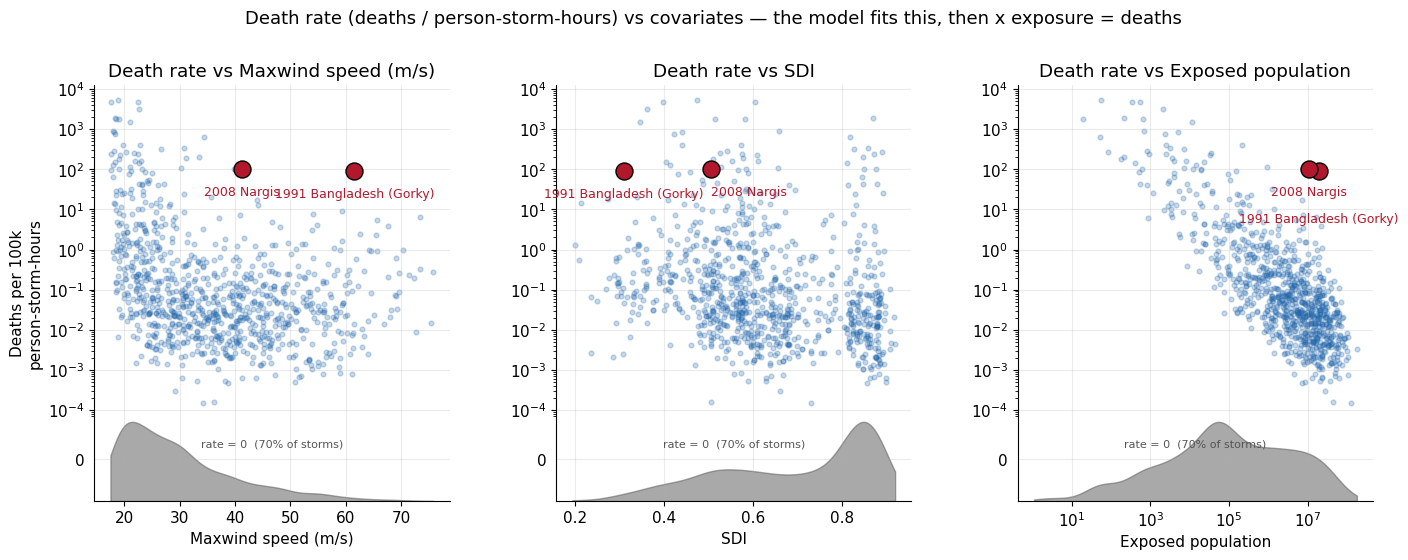

In [8]:
# Rate scale: deaths per 100k person-storm-hours — the model fits THIS, then x exposure = deaths.
df["rate"] = df.deaths / df.exposed * 1e5
posr = df[df.deaths > 0]
rate_panels = [("wind_speed", "Maxwind speed (m/s)", False),
               ("sdi", "SDI", False),
               ("exposed_population", "Exposed population", True)]
fig = plt.figure(figsize=(16.5, 5.4))
gs = fig.add_gridspec(2, 3, height_ratios=[4, 1], hspace=0, wspace=0.30)
for j, (cov, lab, logx) in enumerate(rate_panels):
    axs = fig.add_subplot(gs[0, j])
    axd = fig.add_subplot(gs[1, j], sharex=axs)
    axs.scatter(posr[cov], posr.rate, s=12, alpha=0.25, color=C_MODEL)
    axs.set_yscale("log")
    if logx:
        axs.set_xscale("log")
    for g in giants:
        gr = g.deaths / g.exposed * 1e5
        nm = names[g.storm_id]
        axs.scatter(g[cov], gr, s=150, color=C_HL, edgecolor="black", zorder=5)
        stack = cov in ("exposed", "exposed_population")
        dy = (-12 if nm == "2008 Nargis" else -30) if stack else -12
        ha = "left" if (nm == "2008 Nargis" and cov == "sdi") else "center"
        axs.annotate(nm, (g[cov], gr), textcoords="offset points",
                     xytext=(0, dy), ha=ha, va="top", fontsize=9, color=C_HL)
    if j == 0:
        axs.set_ylabel("Deaths per 100k\nperson-storm-hours", y=0.375)
    axs.set_title(f"Death rate vs {lab}")
    axs.tick_params(labelbottom=False, bottom=False)
    axs.spines["bottom"].set_visible(False)
    z = df.loc[df.deaths == 0, cov].values
    if logx:
        grid = np.linspace(np.log10(df[cov].min()), np.log10(df[cov].max()), 200)
        axd.fill_between(10.0 ** grid, gaussian_kde(np.log10(z))(grid), color=C_MED, alpha=0.5)
    else:
        xs = np.linspace(df[cov].min(), df[cov].max(), 200)
        axd.fill_between(xs, gaussian_kde(z)(xs), color=C_MED, alpha=0.5)
    axd.set_ylim(bottom=0)
    axd.set_yticks([axd.get_ylim()[1] / 2], ["0"])
    axd.tick_params(left=False)
    axd.set_xlabel(lab)
    axd.text(0.5, 0.75, f"rate = 0  ({100*zero_frac:.0f}% of storms)",
             transform=axd.transAxes, ha="center", va="top", fontsize=8, color=C_MED)
fig.suptitle("Death rate (deaths / person-storm-hours) vs covariates — the model fits this, then x exposure = deaths",
             fontsize=13, y=1.02)
fig.tight_layout(h_pad=0)
plt.show()

On the rate scale the two catastrophes jump out: both sit at the **99th percentile of rate**
(~100 deaths per 100k people-storm-hours, versus a median of 0.05). So the toll is a product —
**elevated exposure (86th pct) × an extreme rate (99th pct)** — and it is the *rate*, not wind, SDI, or
exposure, that is the un-modelable extreme. (Neither factor is at its single maximum: a few tiny-exposure
storms have even higher rates but killed almost no one. The catastrophe is the rare co-occurrence of a
high rate *and* high exposure — and the rate is the heavy-tailed piece, the α < 1 tail from Part 3.)

For completeness, the other exposure normalization — **deaths per exposed *person*** (deaths /
exposed_population), a per-capita mortality rate — tells the same story:

/tmp/ipykernel_160398/154435616.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=0)


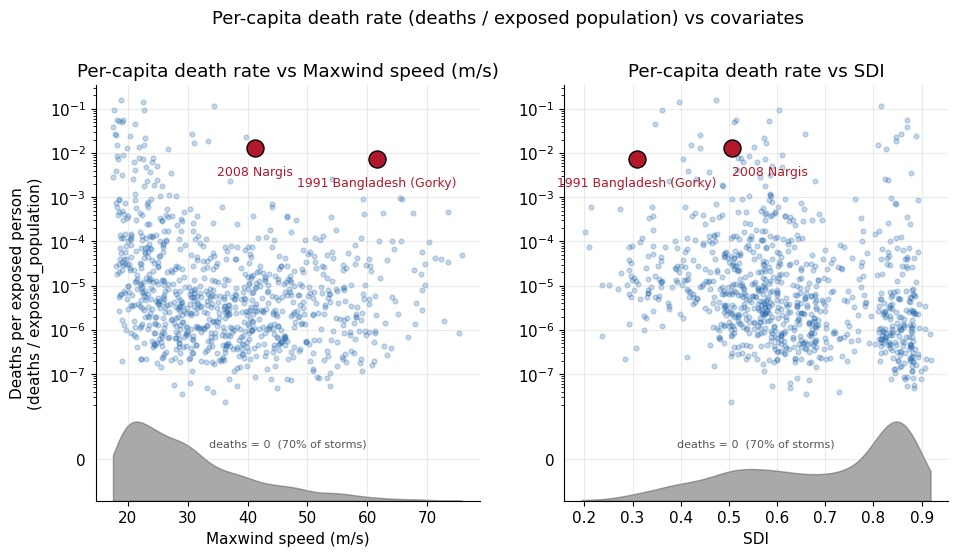

In [9]:
# Per-capita: deaths per exposed PERSON (deaths / exposed_population) — the other normalization.
df["pcap"] = df.deaths / df.exposed_population
posc = df[df.deaths > 0]
pcap_panels = [("wind_speed", "Maxwind speed (m/s)", False), ("sdi", "SDI", False)]
fig = plt.figure(figsize=(11, 5.4))
gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0, wspace=0.22)
for j, (cov, lab, logx) in enumerate(pcap_panels):
    axs = fig.add_subplot(gs[0, j])
    axd = fig.add_subplot(gs[1, j], sharex=axs)
    axs.scatter(posc[cov], posc.pcap, s=12, alpha=0.25, color=C_MODEL)
    axs.set_yscale("log")
    if logx:
        axs.set_xscale("log")
    for g in giants:
        gp = g.deaths / g.exposed_population
        nm = names[g.storm_id]
        axs.scatter(g[cov], gp, s=150, color=C_HL, edgecolor="black", zorder=5)
        ha = "left" if (nm == "2008 Nargis" and cov == "sdi") else "center"
        axs.annotate(nm, (g[cov], gp), textcoords="offset points", xytext=(0, -12),
                     ha=ha, va="top", fontsize=9, color=C_HL)
    if j == 0:
        axs.set_ylabel("Deaths per exposed person\n(deaths / exposed_population)", y=0.375)
    axs.set_title(f"Per-capita death rate vs {lab}")
    axs.tick_params(labelbottom=False, bottom=False)
    axs.spines["bottom"].set_visible(False)
    z = df.loc[df.deaths == 0, cov].values
    xs = np.linspace(df[cov].min(), df[cov].max(), 200)
    axd.fill_between(xs, gaussian_kde(z)(xs), color=C_MED, alpha=0.5)
    axd.set_ylim(bottom=0)
    axd.set_yticks([axd.get_ylim()[1] / 2], ["0"])
    axd.tick_params(left=False)
    axd.set_xlabel(lab)
    axd.text(0.5, 0.75, f"deaths = 0  ({100*zero_frac:.0f}% of storms)",
             transform=axd.transAxes, ha="center", va="top", fontsize=8, color=C_MED)
fig.suptitle("Per-capita death rate (deaths / exposed population) vs covariates", fontsize=13, y=1.02)
fig.tight_layout(h_pad=0)
plt.show()

Same shape per-capita: the giants sit high (Gorky ~0.7%, Nargis ~1.3% of exposed people died) but
not at the wind/SDI extremes, and most storms at any covariate value killed a negligible fraction. The
exposure denominator you pick (person-storm-hours vs headcount) changes the units, not the conclusion.
Here is the full distribution of the per-capita rate, global and by basin:

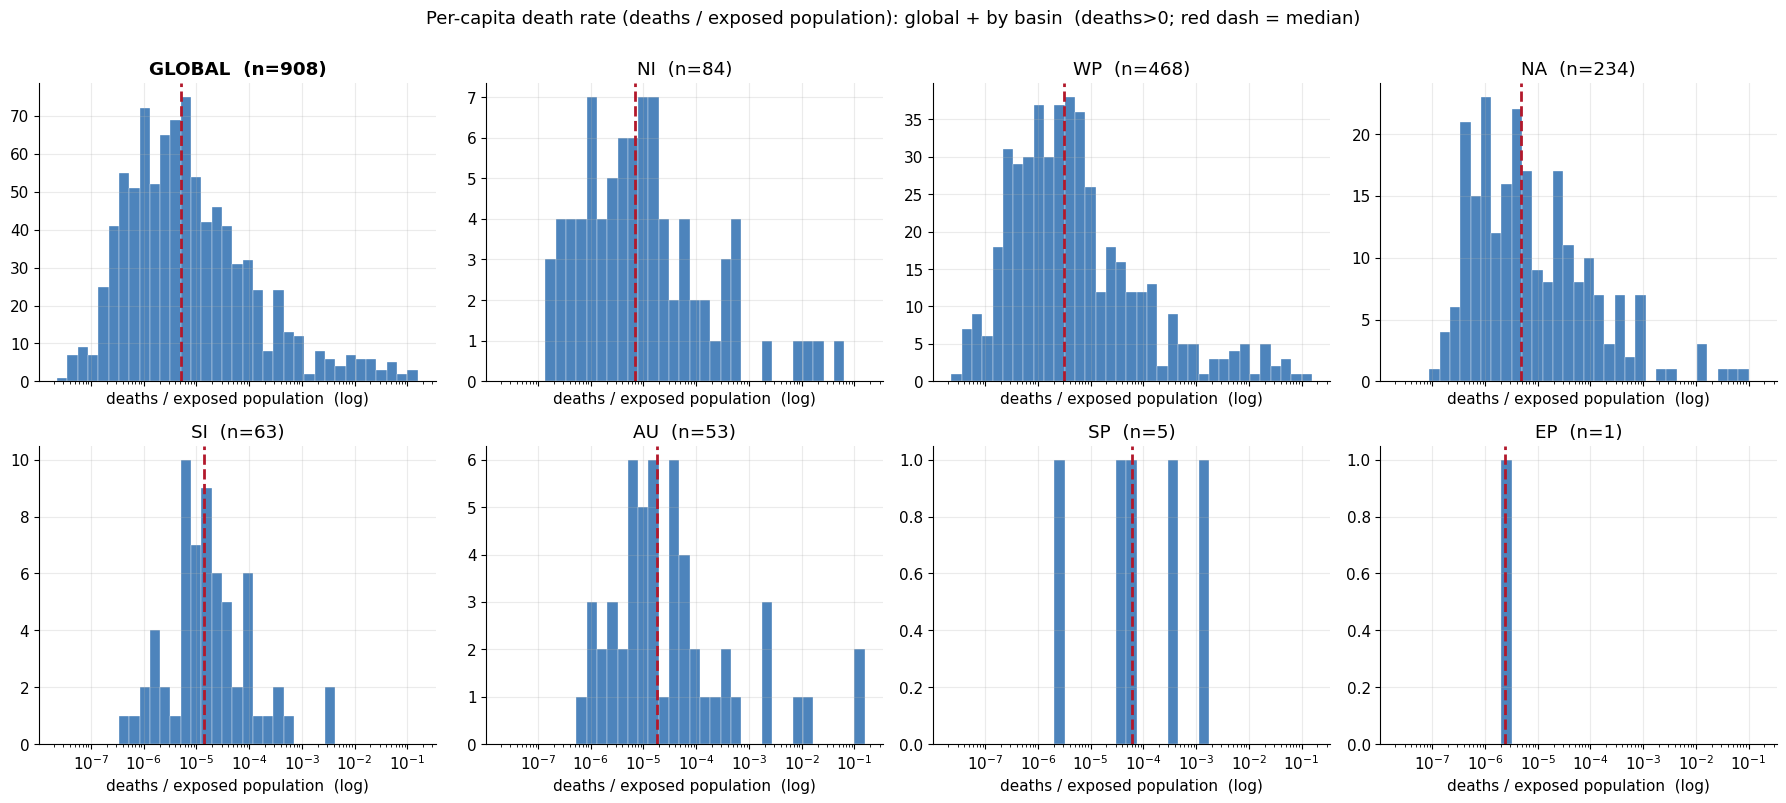

In [10]:
# Per-capita death-rate distribution: GLOBAL + one panel per basin (deaths>0; log x-axis, since
# pcap spans ~7 orders of magnitude; the 2,116 deaths=0 rows have pcap=0 and can't sit on a log axis).
d_pc = df[df.deaths > 0]
order_pc = d_pc.groupby("basin").deaths.sum().sort_values(ascending=False).index.tolist()
bins_pc = np.logspace(np.log10(d_pc.pcap.min()), np.log10(d_pc.pcap.max()), 36)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.ravel()
axes[0].hist(d_pc.pcap, bins=bins_pc, color=C_MODEL, alpha=0.8, edgecolor="white", lw=0.3)
axes[0].axvline(d_pc.pcap.median(), color=C_HL, lw=2, ls="--")
axes[0].set_xscale("log"); axes[0].set_title(f"GLOBAL  (n={len(d_pc)})", fontweight="bold")
for k, b in enumerate(order_pc, start=1):
    ax = axes[k]; sub = d_pc[d_pc.basin == b]
    ax.hist(sub.pcap, bins=bins_pc, color=C_MODEL, alpha=0.8, edgecolor="white", lw=0.3)
    ax.axvline(sub.pcap.median(), color=C_HL, lw=2, ls="--")
    ax.set_xscale("log"); ax.set_title(f"{b}  (n={len(sub)})")
for k in range(len(order_pc) + 1, len(axes)):
    axes[k].set_visible(False)
for ax in axes:
    ax.set_xlabel("deaths / exposed population  (log)")
fig.suptitle("Per-capita death rate (deaths / exposed population): global + by basin  "
             "(deaths>0; red dash = median)", fontsize=13, y=1.0)
fig.tight_layout(); plt.show()

Within each basin the per-capita rate is roughly **log-normal** (bell-shaped on the log axis),
medians clustered around 1e-5–1e-4. The distribution's **maximum (15.7%)** is a *small-denominator*
storm (2015 Solomon Islands: 9 deaths / 57 exposed), **not** a mega-event — the catastrophes by toll
(Nargis ~1.3%, Gorky ~0.7%) sit in their basin's upper range, elevated by huge denominators, not by
per-capita extremity. Now the *where*:

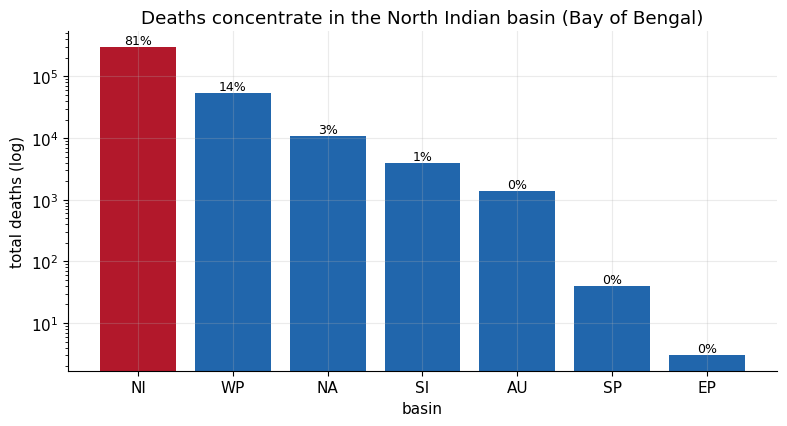

In [11]:
# Figure B: total deaths by basin — is it really the Bay of Bengal?
bd = df.groupby("basin").deaths.sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.4))
cols = [C_HL if b == "NI" else C_MODEL for b in bd.index]
ax.bar(bd.index, bd.values, color=cols)
ax.set_yscale("log"); ax.set_xlabel("basin"); ax.set_ylabel("total deaths (log)")
ax.set_title("Deaths concentrate in the North Indian basin (Bay of Bengal)")
for i, (b, v) in enumerate(bd.items()):
    ax.text(i, v, f"{100*v/tot:.0f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

### Second view — within each basin (wind only)
Faceting by basin (deaths>0, OLS trend on log10 y) separates **two different confounds** — and they
behave differently:

- **Deaths vs wind flips to positive within basin** (NI +0.03, NA/SI +0.01, WP ~0). The pooled negative
  was **Simpson's paradox** — the deadliest basin (North Indian) has modest winds — and it disappears
  once basin is held fixed. This matches S1's fitted **+wind** (+0.038: more wind → more likely a death).
- **Rate and per-capita vs wind stay negative even within basin** (slopes ≈ −0.03 to −0.06; NI ~0). Here
  basin is *not* the culprit — **exposure** is: higher-wind storms carry far more person-storm-hours, so
  deaths-*per-exposure* falls with wind. The model absorbs this with `log_exposed` as a covariate (S2
  coef −1.15); its fitted **+wind (+0.028)** is the effect *holding exposure fixed*, which a raw marginal
  scatter simply can't display.

Bottom line: the model's fitted directions are reasonable. The deaths-vs-wind negative was basin
confounding (removed here); the rate-vs-wind negative is a real exposure effect the model already
adjusts for — neither is a fit problem.

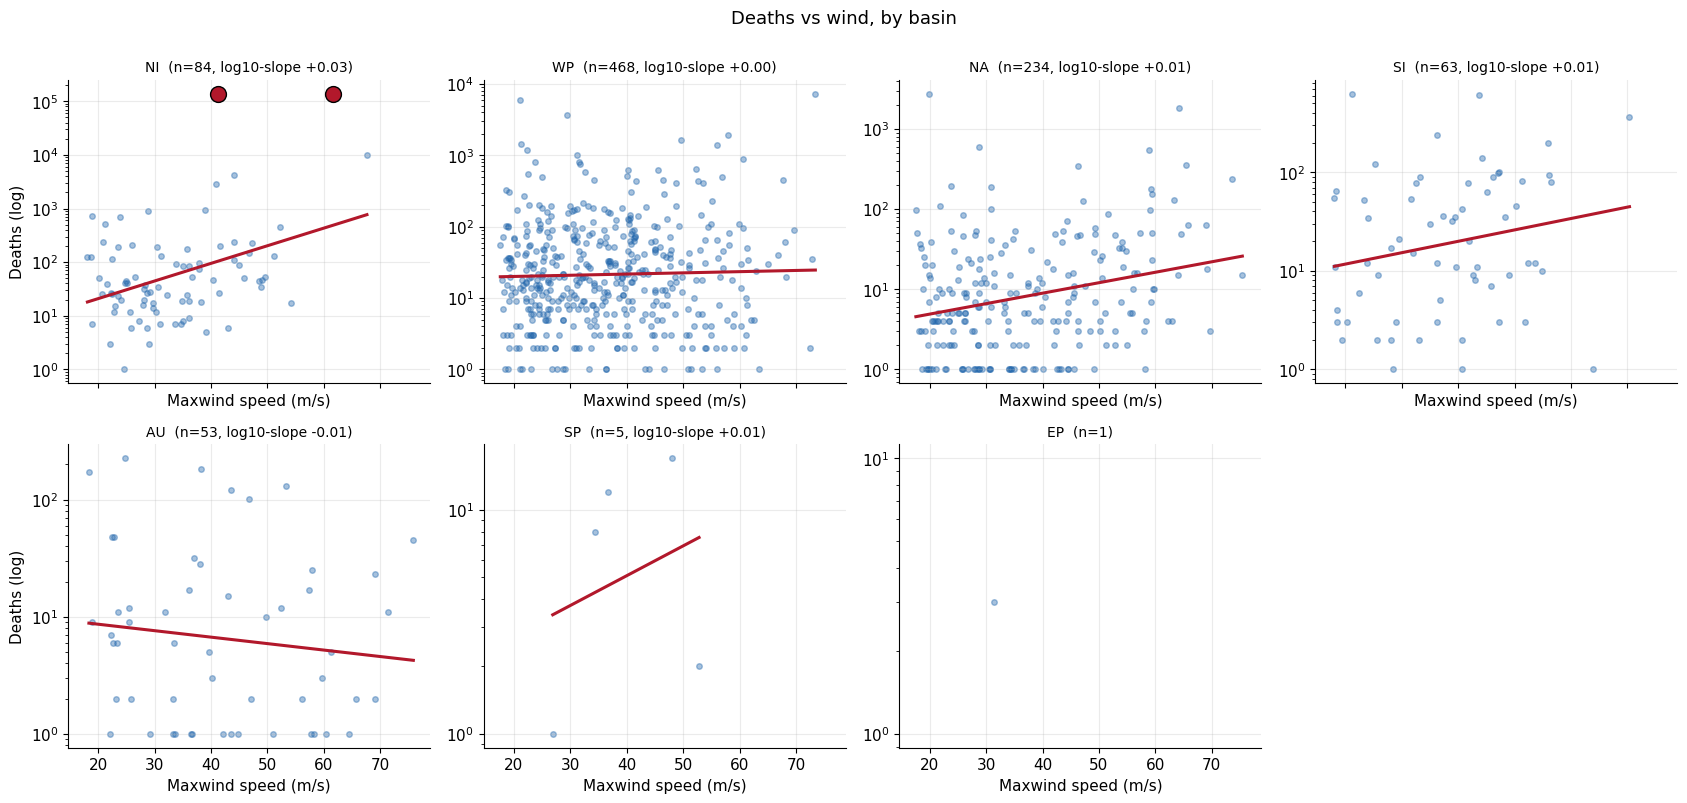

In [12]:
per_basin_vs_wind("deaths", "Deaths (log)", "Deaths vs wind, by basin")

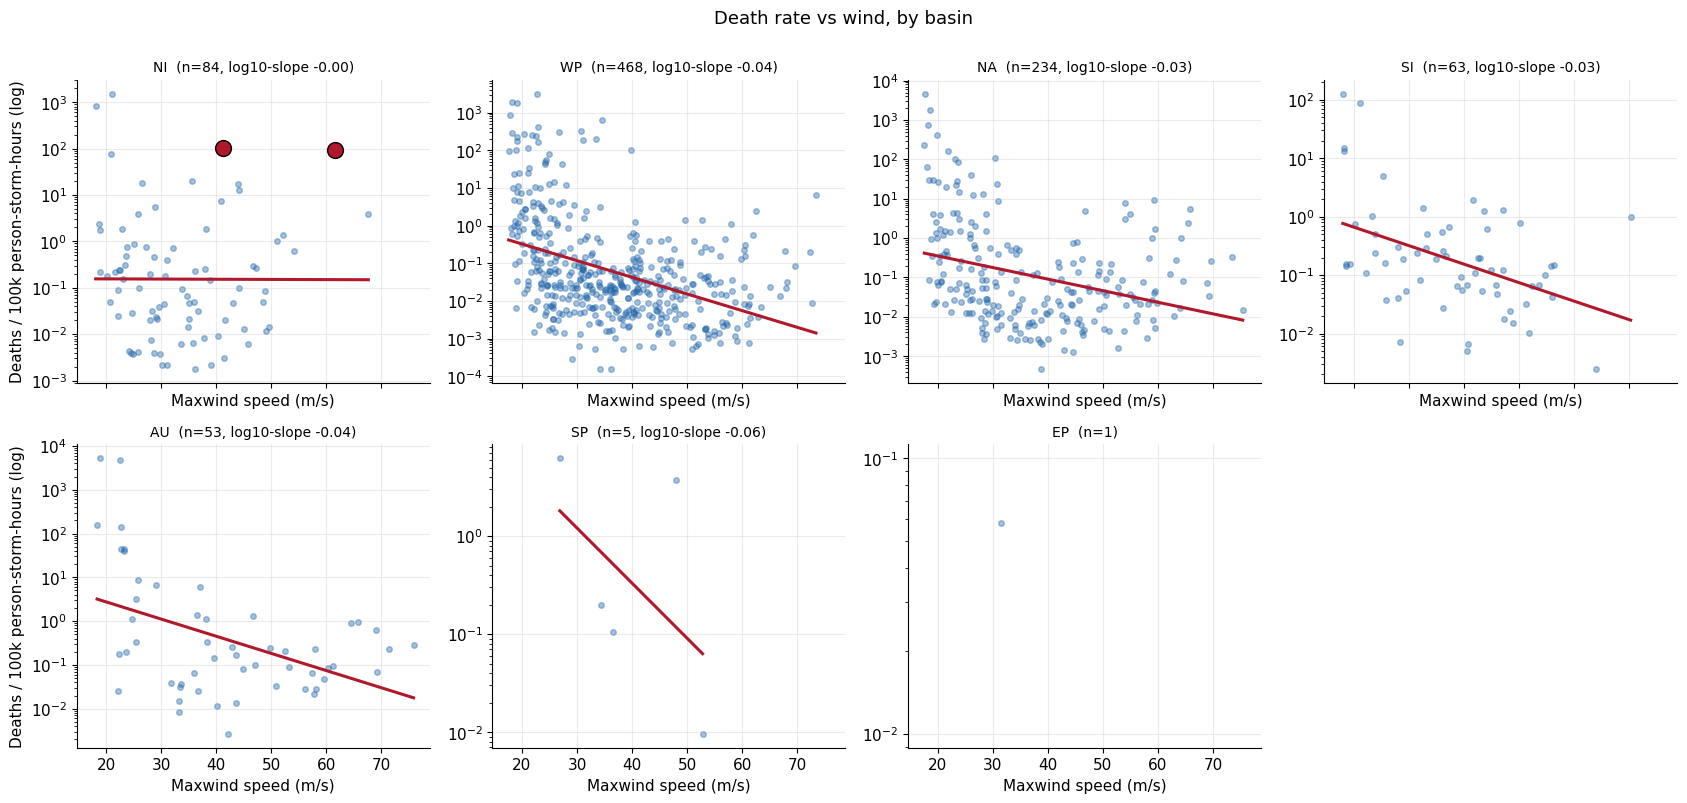

In [13]:
per_basin_vs_wind("rate", "Deaths / 100k person-storm-hours (log)", "Death rate vs wind, by basin")

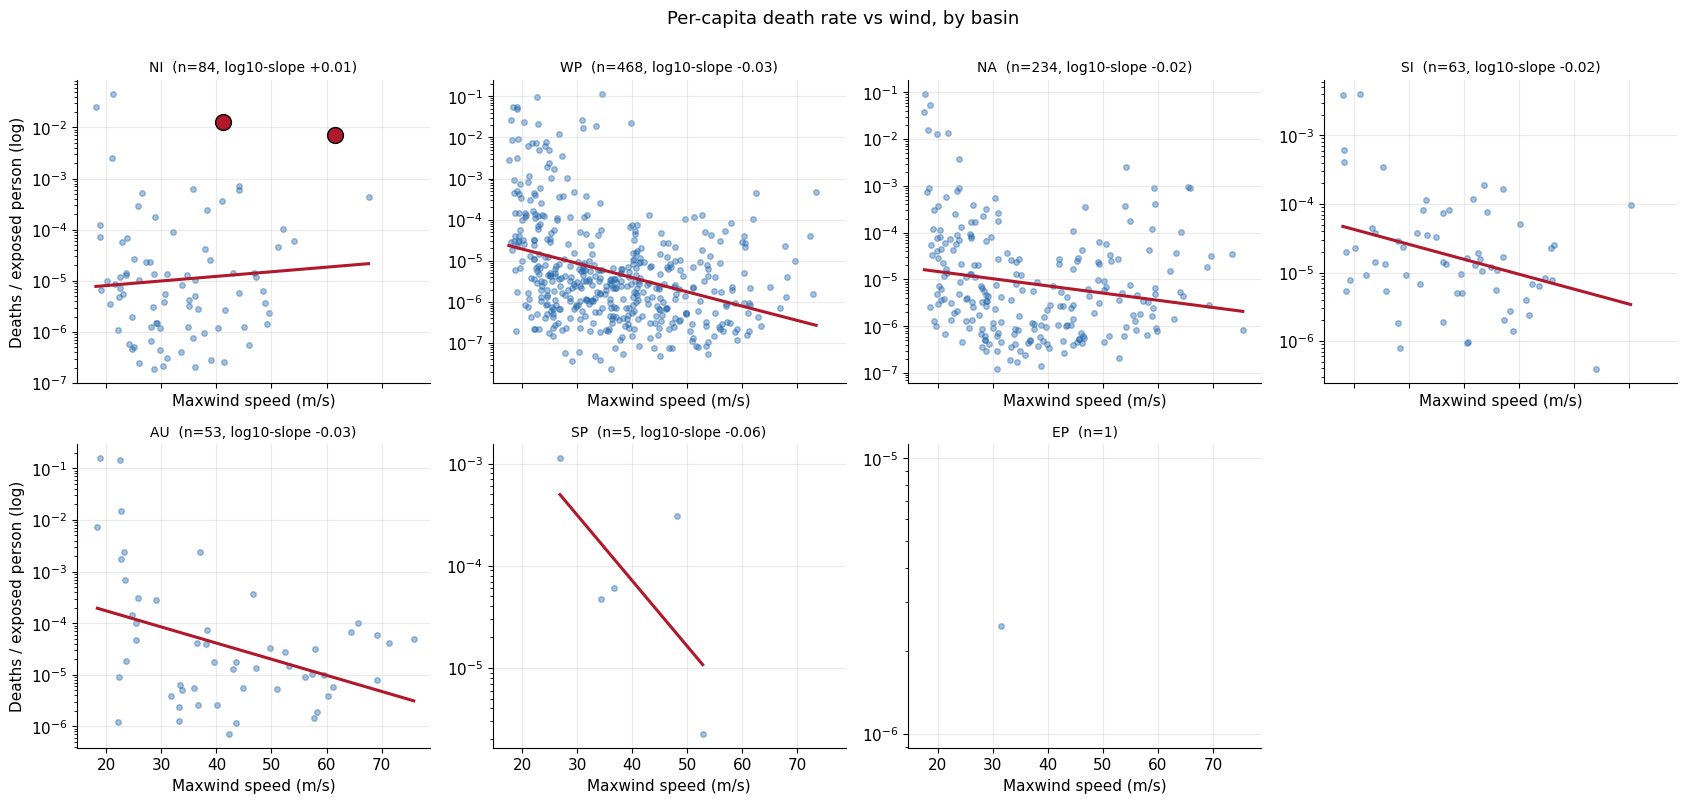

In [14]:
per_basin_vs_wind("pcap", "Deaths / exposed person (log)", "Per-capita death rate vs wind, by basin")

### So *can* we show the exposure-adjusted wind effect? Yes — two ways.
First the mechanism: `duration = person-storm-hours / exposed_population` (avg hours a person is exposed)
**rises steadily with wind** (corr +0.41). Stronger storms expose people longer, so person-storm-hours
grow faster than deaths — dropping the per-PSH rate.

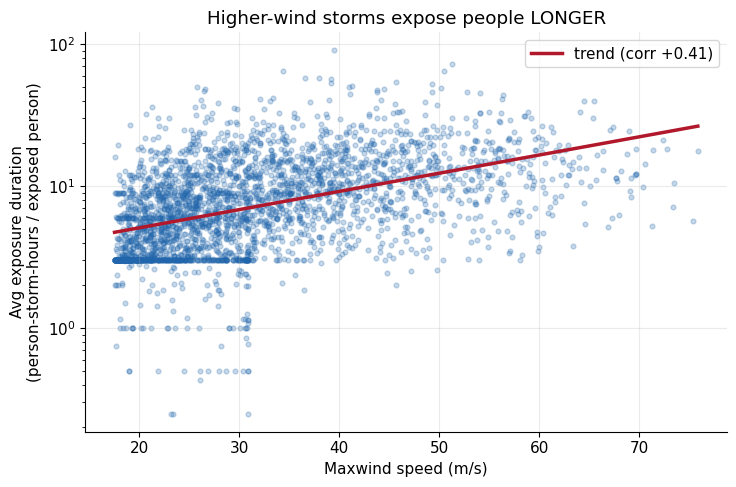

In [15]:
# Avg exposure duration (PSH / exposed_population) vs wind — the mechanism behind the confound.
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(df.wind_speed, df.duration, s=12, alpha=0.25, color=C_MODEL)
ax.set_yscale("log")
b1, b0 = np.polyfit(df.wind_speed, np.log10(df.duration), 1)
xg = np.linspace(df.wind_speed.min(), df.wind_speed.max(), 50)
r = np.corrcoef(df.wind_speed, df.duration)[0, 1]
ax.plot(xg, 10.0 ** (b0 + b1 * xg), color=C_HL, lw=2.5, label=f"trend (corr {r:+.2f})")
ax.set_xlabel("Maxwind speed (m/s)")
ax.set_ylabel("Avg exposure duration\n(person-storm-hours / exposed person)")
ax.set_title("Higher-wind storms expose people LONGER")
ax.legend(); plt.tight_layout(); plt.show()

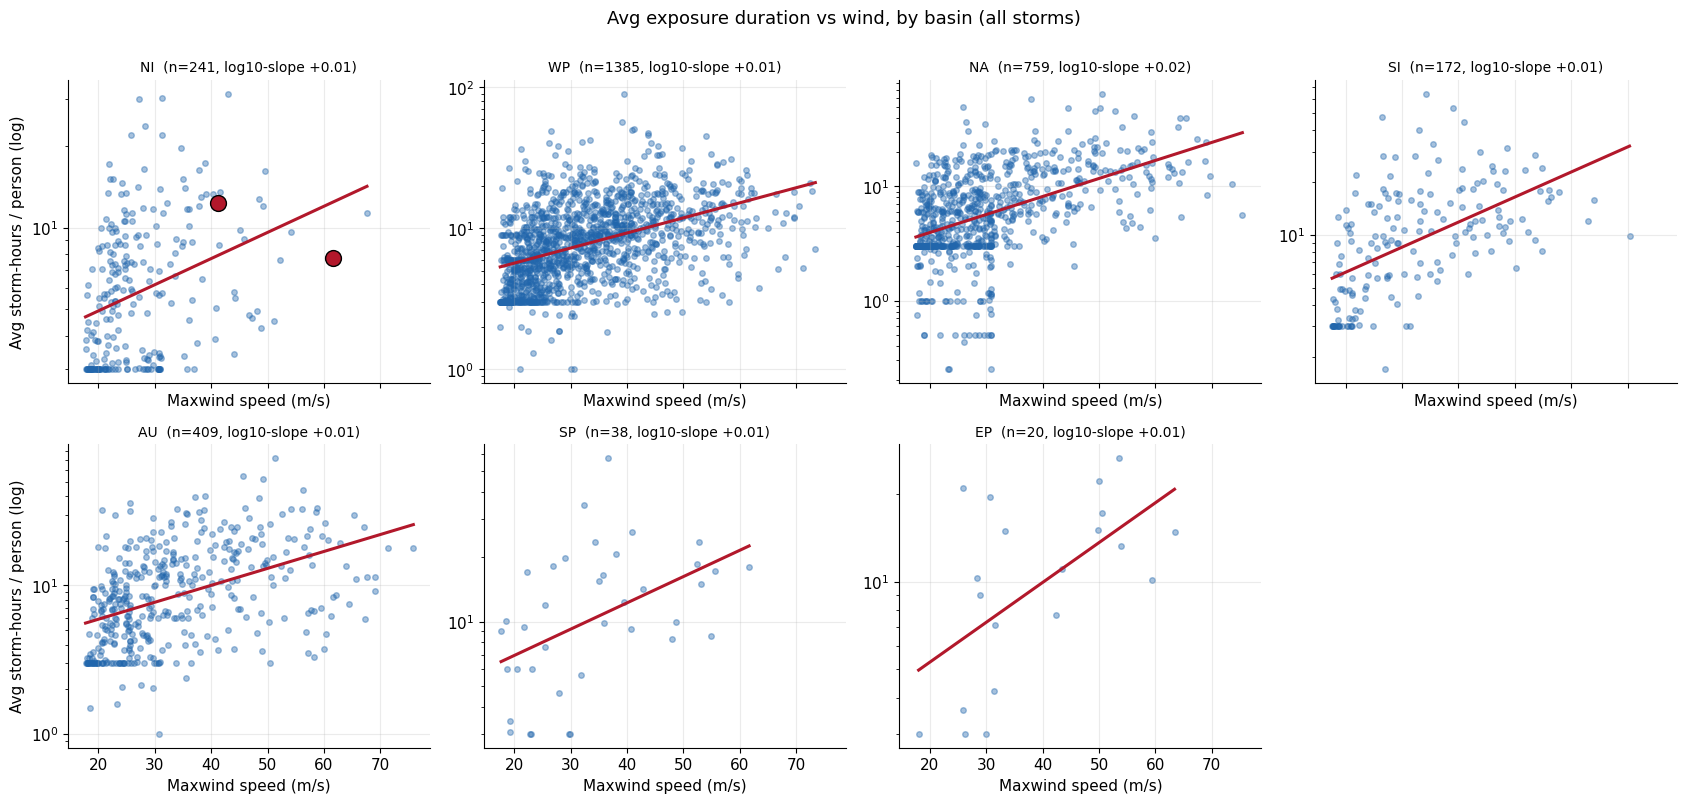

In [16]:
per_basin_vs_wind("duration", "Avg storm-hours / person (log)",
                  "Avg exposure duration vs wind, by basin (all storms)", pos_only=False)

And the plot that literally shows *wind holding exposure fixed* — an **added-variable plot**: wind
and log(rate) are each residualized on exposure + SDI + basin, then scattered. The raw (marginal) slope
is negative; the partial slope flips **positive** — which is the direction the model fits.

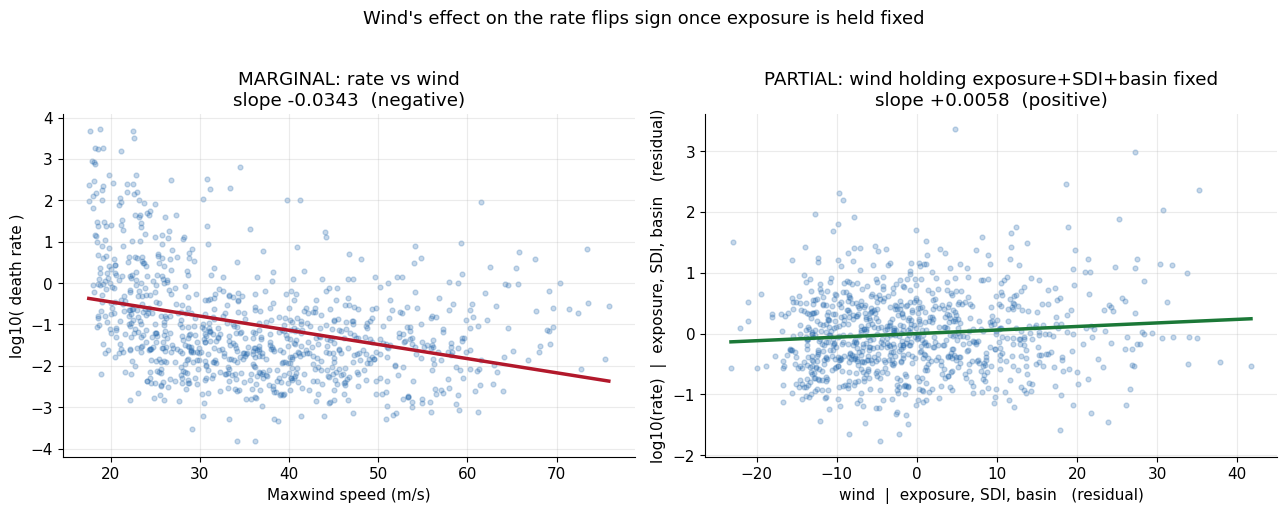

In [17]:
# Wind's effect on log10(rate): MARGINAL vs PARTIAL (holding exposure + SDI + basin fixed).
d = df[df.deaths > 0].copy()
lr = np.log10(d.rate.values); w = d.wind_speed.values
basins = ["NA", "NI", "AU", "SI", "SP", "WP"]           # EP = reference level
C = np.column_stack([np.ones(len(d)), np.log(d.exposed.values), d.sdi.values]
                    + [(d.basin == b).astype(float).values for b in basins])
def _resid(v):
    beta, *_ = np.linalg.lstsq(C, v, rcond=None)
    return v - C @ beta
rw, rlr = _resid(w), _resid(lr)
m_slope = np.polyfit(w, lr, 1)[0]
p_slope = np.polyfit(rw, rlr, 1)[0]

fig, (axm, axp) = plt.subplots(1, 2, figsize=(13, 5))
axm.scatter(w, lr, s=12, alpha=0.25, color=C_MODEL)
xg = np.linspace(w.min(), w.max(), 50)
axm.plot(xg, np.polyval(np.polyfit(w, lr, 1), xg), color=C_HL, lw=2.5)
axm.set_xlabel("Maxwind speed (m/s)")
axm.set_ylabel("log10( death rate )")
axm.set_title(f"MARGINAL: rate vs wind\nslope {m_slope:+.4f}  (negative)")
axp.scatter(rw, rlr, s=12, alpha=0.25, color=C_MODEL)
xg2 = np.linspace(rw.min(), rw.max(), 50)
axp.plot(xg2, np.polyval(np.polyfit(rw, rlr, 1), xg2), color="#1b7837", lw=2.5)
axp.set_xlabel("wind  |  exposure, SDI, basin   (residual)")
axp.set_ylabel("log10(rate)  |  exposure, SDI, basin   (residual)")
axp.set_title(f"PARTIAL: wind holding exposure+SDI+basin fixed\nslope {p_slope:+.4f}  (positive)")
fig.suptitle("Wind's effect on the rate flips sign once exposure is held fixed", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Verdict.** The covariates carry real, strong signal about *where* deaths happen: the North
Indian basin (Bay of Bengal) is 8% of storm-locations but 81% of all deaths, and low SDI carries the
bulk of the rest. A covariate-dependent model uses exactly this. What the covariates **cannot** do is
predict the **magnitude**: 70% of storms kill nobody, the two catastrophes sit at ordinary covariate
values (same basin, but Nargis is mid-pack on wind and unremarkable on SDI — quite different from
Gorky), and countless same-basin, similar-covariate storms killed a handful of people or none. Combined
with α < 1 (Part 3), the size of the next catastrophe is not a function of the covariates — which is why
no model predicts the total, and the level is corrected empirically instead.

(Honest caveat: with only two catastrophes, the *magnitude*-unpredictability is a low-power claim; the
*where*-signal, resting on all 3,024 storm-locations, is solid.)